
Processing Ethiopia...
Ethiopia duplicates: 0
Ethiopia missing (%):
 YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
Date           0.0
Month          0.0
Year           0.0
dtype: float64
Ethiopia total outliers: 137

Processing Kenya...
Kenya duplicates: 0
Kenya missing (%):
 YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
Date           0.0
Month          0.0
Year           0.0
dtype: float64
Kenya total outliers: 124

Processing Nigeria...
Nigeria duplicates: 0
Nigeria missing (%):
 YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE     

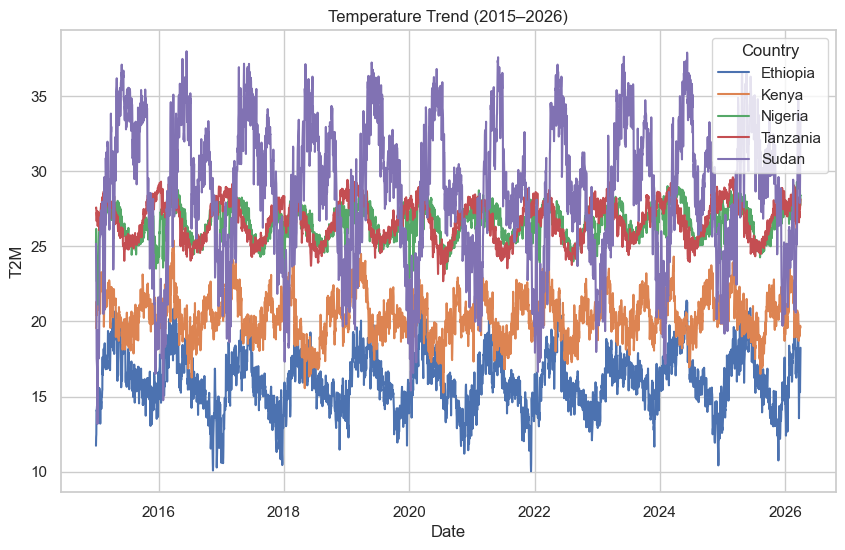

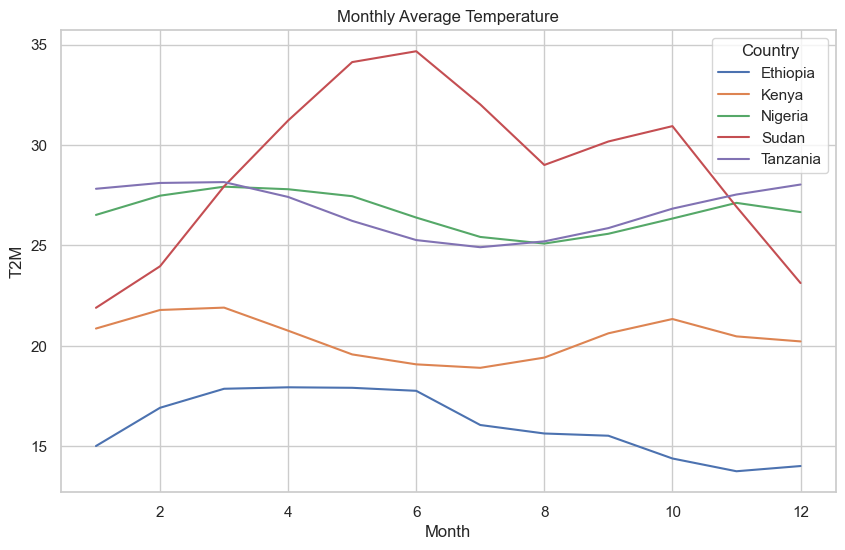

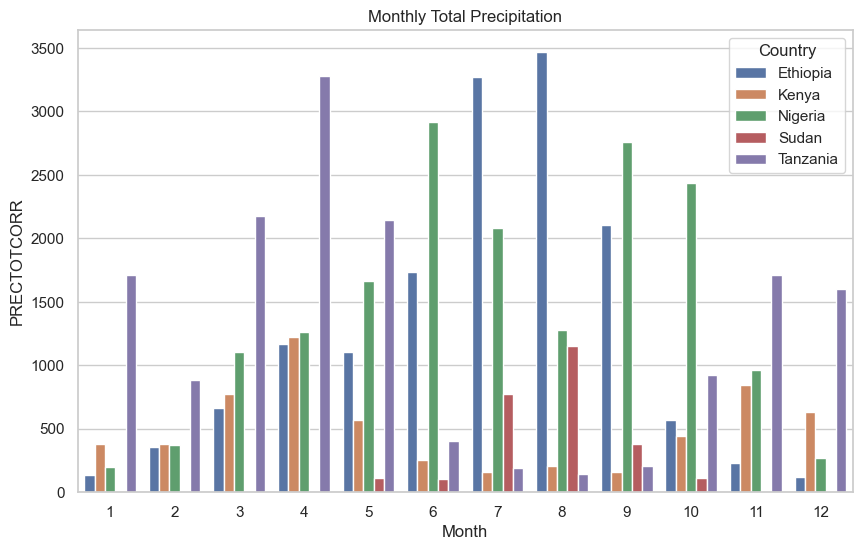

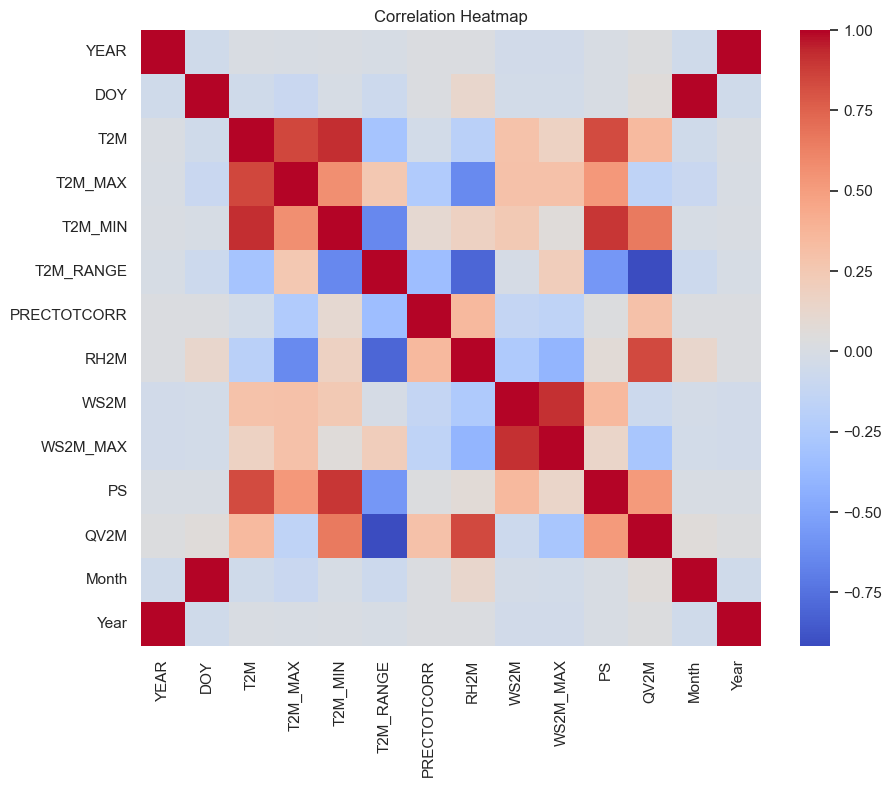

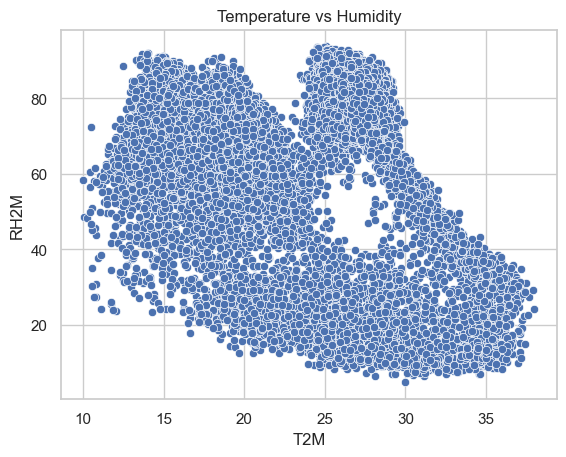

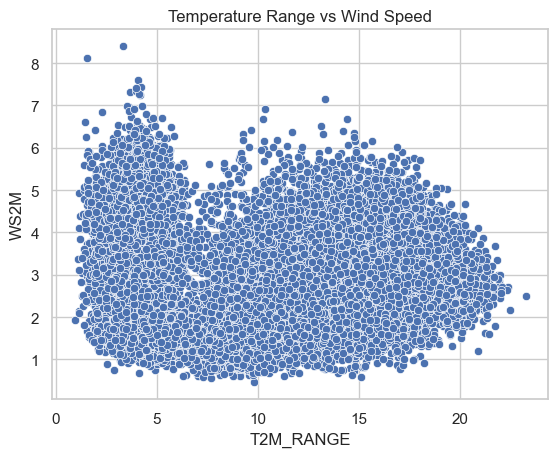

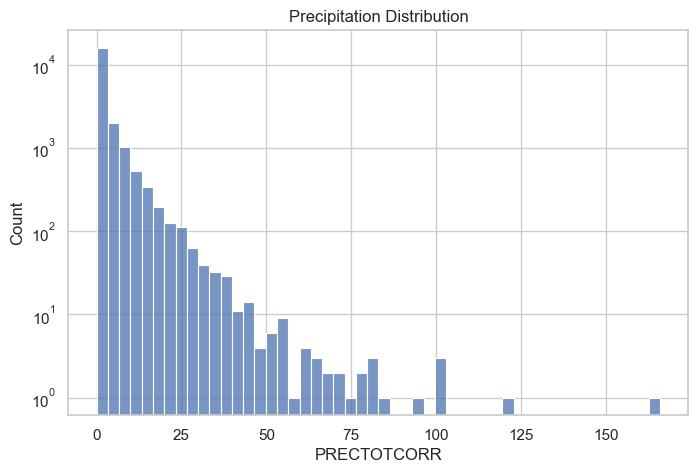

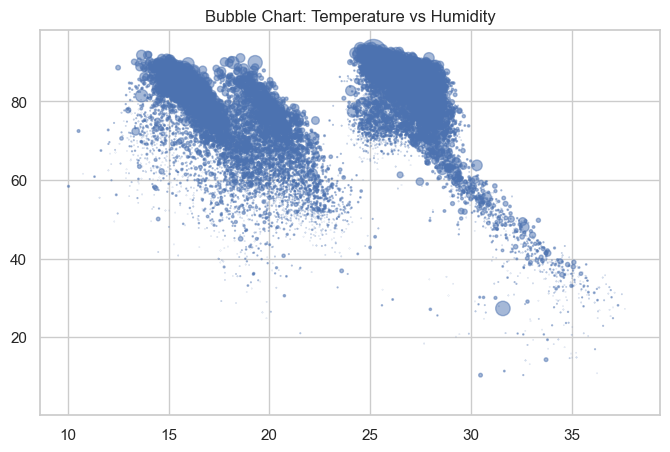

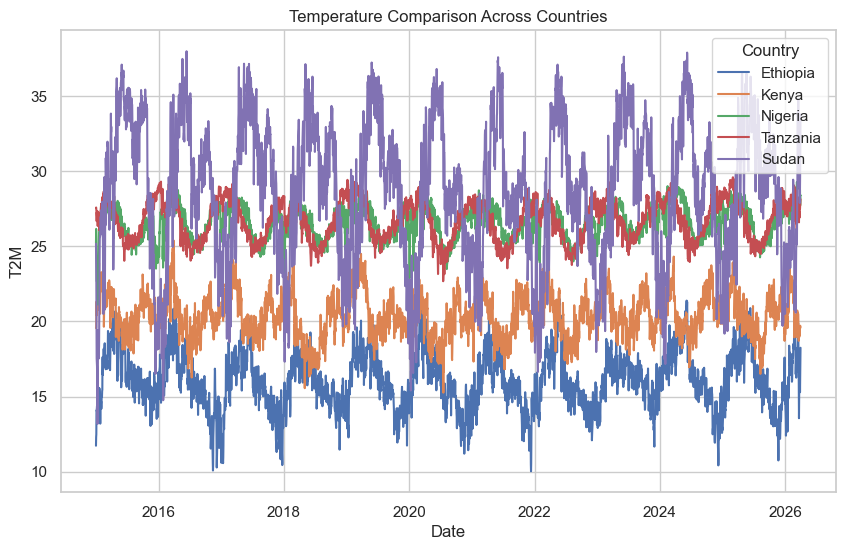

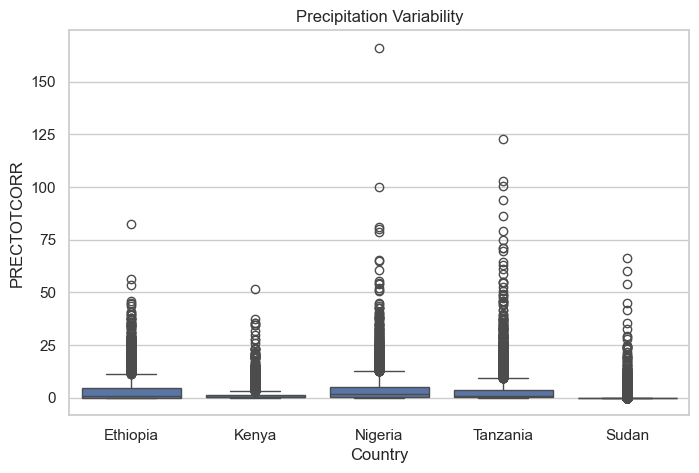

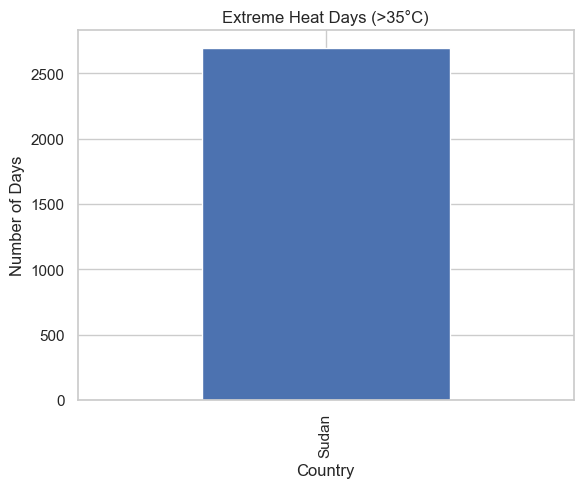

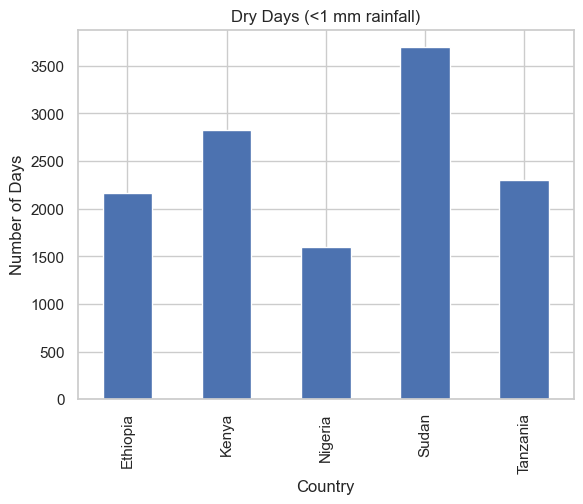


Temperature Summary:
                mean  median       std
Country                              
Ethiopia  16.068500   16.04  1.898050
Kenya     20.427600   20.36  1.440824
Nigeria   26.656928   26.82  1.123335
Sudan     28.759007   29.16  4.681305
Tanzania  26.802422   26.99  1.325388

Rainfall Summary:
               mean  median       std
Country                             
Ethiopia  3.633795    0.82  6.289061
Kenya     1.468162    0.38  3.180228
Nigeria   4.213914    1.84  7.266742
Sudan     0.643875    0.00  3.057672
Tanzania  3.740256    0.64  8.003947

ANOVA p-value: 0.0
Temperature differences are statistically significant

Climate Vulnerability Ranking:
                mean  median       std
Country                              
Sudan     28.759007   29.16  4.681305
Tanzania  26.802422   26.99  1.325388
Nigeria   26.656928   26.82  1.123335
Kenya     20.427600   20.36  1.440824
Ethiopia  16.068500   16.04  1.898050


In [ ]:
# =========================================
# AFRICAN CLIMATE ANALYSIS PIPELINE
# =========================================

"""
This notebook performs climate data analysis for five African countries.
Steps:
1. Load and clean data
2. Perform exploratory data analysis (EDA)
3. Compare countries and evaluate climate vulnerability
"""

# =========================================
# IMPORTS
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway

sns.set(style="whitegrid")

# =========================================
# FILE PATHS
# =========================================

files = {
    "Ethiopia": "ethiopia.csv",
    "Kenya": "kenya.csv",
    "Nigeria": "nigeria.csv",
    "Tanzania": "tanzania.csv",
    "Sudan": "sudan.csv"
}

# =========================================
# FUNCTION: LOAD AND CLEAN DATA
# =========================================

def load_and_clean_data(country, file):
    """
    Load and clean dataset for a given country.

    Steps:
    - Load CSV
    - Convert date
    - Handle missing values
    - Remove duplicates
    - Detect outliers

    Returns:
        Cleaned DataFrame
    """

    print(f"\nProcessing {country}...")

    df = pd.read_csv(f"../data/{file}")

    # Add country column
    df["Country"] = country

    # Convert YEAR + DOY into datetime
    df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
    df["Month"] = df["Date"].dt.month
    df["Year"] = df["Date"].dt.year

    # Replace missing values (-999 is NASA sentinel value)
    df.replace(-999, np.nan, inplace=True)

    # Remove duplicates
    duplicates = df.duplicated().sum()
    print(f"{country} duplicates:", duplicates)
    df.drop_duplicates(inplace=True)

    # Missing value percentage
    missing_percent = df.isna().mean() * 100
    print(f"{country} missing (%):\n", missing_percent)

    # Handle missing values using forward-fill
    # This is appropriate for time-series data to preserve continuity
    df = df.ffill()

    # Drop rows with excessive missing values (>30%)
    df = df.dropna(thresh=int(0.7 * len(df.columns)))

    # Outlier detection using Z-score
    numeric_cols = ['T2M','T2M_MAX','T2M_MIN','PRECTOTCORR','RH2M','WS2M','WS2M_MAX']
    z_scores = np.abs(stats.zscore(df[numeric_cols], nan_policy='omit'))
    outliers = (z_scores > 3)

    print(f"{country} total outliers:", outliers.sum().sum())

    # Note: Outliers are kept because they represent real extreme climate events

    # Save cleaned dataset
    df.to_csv(f"{country.lower()}_clean.csv", index=False)

    return df

# =========================================
# FUNCTION: PLOT TEMPERATURE TREND
# =========================================

def plot_temperature_trend(df):
    """Plot temperature trend over time."""
    plt.figure(figsize=(10,6))
    sns.lineplot(data=df, x="Date", y="T2M", hue="Country")
    plt.title("Temperature Trend (2015–2026)")
    plt.show()

# =========================================
# FUNCTION: PLOT MONTHLY TEMPERATURE
# =========================================

def plot_monthly_temperature(df):
    """Plot monthly average temperature."""
    monthly_temp = df.groupby(["Country","Month"])["T2M"].mean().reset_index()
    plt.figure(figsize=(10,6))
    sns.lineplot(data=monthly_temp, x="Month", y="T2M", hue="Country")
    plt.title("Monthly Average Temperature")
    plt.show()

# =========================================
# FUNCTION: PLOT PRECIPITATION
# =========================================

def plot_precipitation(df):
    """Plot monthly total precipitation."""
    monthly_rain = df.groupby(["Country","Month"])["PRECTOTCORR"].sum().reset_index()
    plt.figure(figsize=(10,6))
    sns.barplot(data=monthly_rain, x="Month", y="PRECTOTCORR", hue="Country")
    plt.title("Monthly Total Precipitation")
    plt.show()

# =========================================
# FUNCTION: CORRELATION HEATMAP
# =========================================
def plot_correlation(df):
    """Plot correlation heatmap."""
    corr = df.select_dtypes(include=np.number).corr()
    plt.figure(figsize=(10,8))
    sns.heatmap(corr, cmap="coolwarm")
    plt.title("Correlation Heatmap")
    plt.show()

# =========================================
# FUNCTION: SCATTER PLOTS
# =========================================

def plot_scatter(df):
    """Plot scatter relationships."""
    sns.scatterplot(data=df, x="T2M", y="RH2M")
    plt.title("Temperature vs Humidity")
    plt.show()

    sns.scatterplot(data=df, x="T2M_RANGE", y="WS2M")
    plt.title("Temperature Range vs Wind Speed")
    plt.show()

# =========================================
# FUNCTION: DISTRIBUTION PLOTS
# =========================================

def plot_distribution(df):
    """Plot precipitation distribution and bubble chart."""
    plt.figure(figsize=(8,5))
    sns.histplot(df["PRECTOTCORR"], bins=50)
    plt.yscale("log")
    plt.title("Precipitation Distribution")
    plt.show()

    plt.figure(figsize=(8,5))
    plt.scatter(df["T2M"], df["RH2M"], 
                s=df["PRECTOTCORR"]*2, alpha=0.5)
    plt.title("Bubble Chart: Temperature vs Humidity")
    plt.show()

# =========================================
# FUNCTION: CROSS-COUNTRY ANALYSIS
# =========================================

def cross_country_analysis(df):
    """Perform cross-country comparison and statistical analysis."""

    # Temperature comparison
    plt.figure(figsize=(10,6))
    sns.lineplot(data=df, x="Date", y="T2M", hue="Country")
    plt.title("Temperature Comparison Across Countries")
    plt.show()

    # Precipitation variability
    plt.figure(figsize=(8,5))
    sns.boxplot(data=df, x="Country", y="PRECTOTCORR")
    plt.title("Precipitation Variability")
    plt.show()

    # Extreme heat
    extreme_heat = df[df["T2M_MAX"] > 35]
    extreme_heat.groupby("Country").size().plot(kind="bar")
    plt.title("Extreme Heat Days (>35°C)")
    plt.ylabel("Number of Days")
    plt.show()

    # Dry days
    dry_days = df[df["PRECTOTCORR"] < 1]
    dry_days.groupby("Country").size().plot(kind="bar")
    plt.title("Dry Days (<1 mm rainfall)")
    plt.ylabel("Number of Days")
    plt.show()

    # Summary statistics
    temp_summary = df.groupby("Country")["T2M"].agg(["mean","median","std"])
    rain_summary = df.groupby("Country")["PRECTOTCORR"].agg(["mean","median","std"])

    print("\nTemperature Summary:\n", temp_summary)
    print("\nRainfall Summary:\n", rain_summary)

    # ANOVA test
    groups = [df[df["Country"] == c]["T2M"].dropna() for c in files.keys()]
    _, p_val = f_oneway(*groups)
    print("\nANOVA p-value:", p_val)

    if p_val < 0.05:
        print("Temperature differences are statistically significant")

    # Vulnerability ranking
    ranking = temp_summary.sort_values(by="mean", ascending=False)
    print("\nClimate Vulnerability Ranking:\n", ranking)

# =========================================
# MAIN EXECUTION
# =========================================

all_dfs = []

for country, file in files.items():
    df = load_and_clean_data(country, file)
    all_dfs.append(df)

# Combine all countries
df_all = pd.concat(all_dfs, ignore_index=True)

# Run analysis
plot_temperature_trend(df_all)
plot_monthly_temperature(df_all)
plot_precipitation(df_all)
plot_correlation(df_all)
plot_scatter(df_all)
plot_distribution(df_all)
cross_country_analysis(df_all)